# package_DBR

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
import package_LAB
from package_LAB import LL_RT, PID_RT, IMC_tuning, Margin

# LL_RT()

In [9]:
help(LL_RT)

Help on function LL_RT in module package_LAB:

LL_RT(MV, Kp, Tlag, Tlead, Ts, PV, PVInit=0, method='EBD')
    The function "FO_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :Tlag: lag time constant [s]
    :Tlead: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)
    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward difference
        EFD: Euler Forward difference
        TRAP: Trapezoïdal method

    The function "FO_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 30.0)

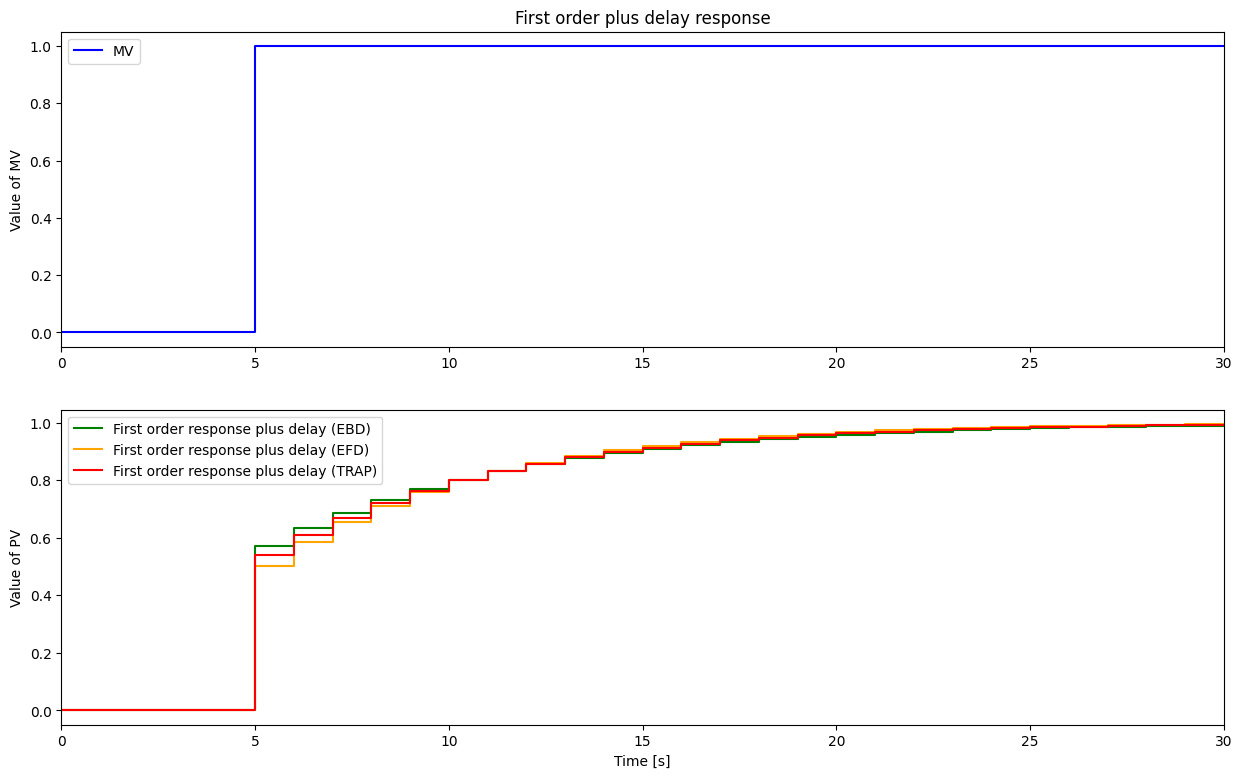

In [10]:
TSim = 30
Ts = 1
N = int(TSim/Ts) + 1

# Path for MV
MVPath = {0: 0, 5: 1, TSim: 1}

t = []
MV = []
PV_EBD = []
PV_EFD = []
PV_TRAP = []

# Parameters
Kp = 1
Tlag = 6
Tlead = 3
theta = 10

for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    LL_RT(MV,Kp,Tlag,Tlead,Ts,PV_EBD)
    LL_RT(MV,Kp,Tlag,Tlead,Ts,PV_EFD,0,'EFD')
    LL_RT(MV,Kp,Tlag,Tlead,Ts,PV_TRAP,0,'TRAP')
    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('First order plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV_EBD,'g-',label='First order response plus delay (EBD)',where='post')
plt.step(t,PV_EFD,'orange',label='First order response plus delay (EFD)',where='post')
plt.step(t,PV_TRAP,'red',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

# PID_RT()

In [11]:
help(PID_RT)

Help on function PID_RT in module package_LAB:

PID_RT(
    SP,
    PV,
    Man,
    MVMan,
    MVFF,
    Kc,
    Ti,
    Td,
    alpha,
    Ts,
    MVMin,
    MVMax,
    MV,
    MVP,
    MVI,
    MVD,
    E,
    ManFF=False,
    PVInit=0,
    method='EBD'
)
    Real-time PID controller with feedforward, manual mode, and anti wind-up.

    Key design choice — anti wind-up excludes MVD:
        MVI_reset = MV_sat - MVP - MVFF   (MVD intentionally excluded)
    MVD is a transient term that decays on its own. Including it in the reset
    causes MVI to jump violently at SP steps, producing an unwanted MV bump.
    The final MV output is hard-clamped to [MVMin, MVMax] instead.



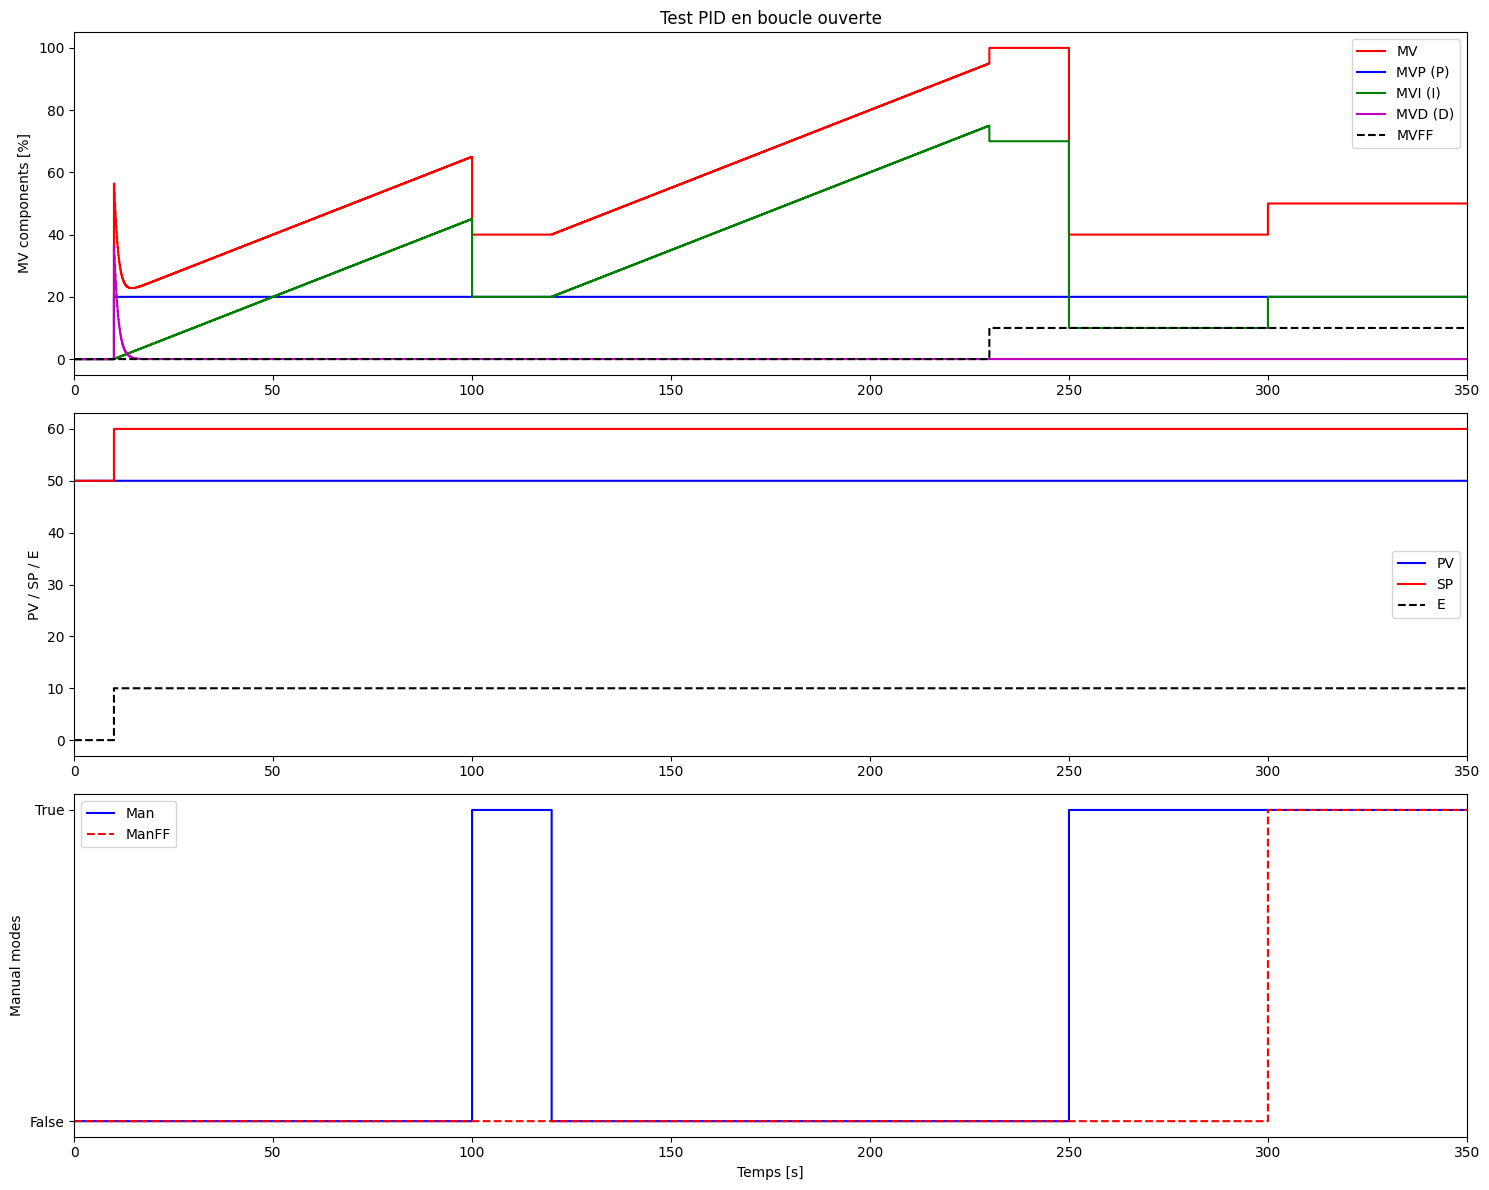

[40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40,

In [12]:
# ============================================================
# Paramètres de simulation
# ============================================================
TSim  = 350
Ts    = 0.1
N     = int(TSim / Ts) + 1
PVInit = 50
# ============================================================
# Paramètres du PID
# ============================================================
Kc    = 2.0
Ti    = 40.0
Td    = 2.0
alpha = 0.5
MVMin = 0.0
MVMax = 100.0

# ============================================================
# Paths des signaux d'entrée
# ============================================================
# Setpoint : échelon de 50 → 60 à t = 10 s
SPPath = {0: 50.0, 10: 60.0}

# Mode Manuel : actif de 100 s à 120 s, puis à nouveau après 230 s
ManPath = {0: False, 100: True, 120: False, 250: True}

MVManPath = {0:40}

# Feedforward : échelon à 10 % à partir de 200 s
MVFFPath = {0: 0.0, 230: 10.0}

# Feedforward Manuel : actif à partir de 240 s
ManFFPath = {0: False, 300: True}

# ============================================================
# Initialisation des vecteurs
# ============================================================
t     = []
SP    = []
Man   = []
MVMan = []
MVFF  = []
ManFF = []

MV    = []
MVP   = []
MVI   = []
MVD   = []
E     = []

MV_Delay = []
PV    = []

# ============================================================
# Boucle de simulation — ordre : FF → PID → Système
# ============================================================
for i in range(N):
    t.append(i * Ts)

    # --- 1. Signaux d'entrée via SelectPath_RT ---
    SelectPath_RT(SPPath,    t, SP)
    SelectPath_RT(ManPath,   t, Man)
    SelectPath_RT(MVManPath, t, MVMan)
    SelectPath_RT(MVFFPath,  t, MVFF)
    SelectPath_RT(ManFFPath, t, ManFF)

    # --- 3. PID ---
    PID_RT(SP, PV, Man, MVMan, MVFF,
           Kc, Ti, Td, alpha, Ts,
           MVMin, MVMax,
           MV, MVP, MVI, MVD, E,
           ManFF=ManFF[-1], PVInit=PVInit)

    # --- 4. Système (boucle ouverte : PV fixe, pas de modèle de procédé) ---
    PV.append(PVInit)


plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
plt.step(t, MV,   'r-',  label='MV',        where='post')
plt.step(t, MVP,  'b-',  label='MVP (P)',    where='post')
plt.step(t, MVI,  'g-',  label='MVI (I)',    where='post')
plt.step(t, MVD,  'm-',  label='MVD (D)',    where='post')
plt.step(t, MVFF, 'k--', label='MVFF',       where='post')
plt.ylabel('MV components [%]')
plt.title('Test PID en boucle ouverte')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(3, 1, 2)
plt.step(t, PV, 'b-',  label='PV', where='post')
plt.step(t, SP, 'r-', label='SP', where='post')
plt.step(t, E,  'k--',  label='E',  where='post')
plt.ylabel('PV / SP / E')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(3, 1, 3)
plt.step(t, [int(m) for m in Man],   'b-',  label='Man',   where='post')
plt.step(t, [int(m) for m in ManFF], 'r--', label='ManFF', where='post')
plt.ylabel('Manual modes')
plt.xlabel('Temps [s]')
plt.yticks([0, 1], ['False', 'True'])
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.tight_layout()
plt.show()
print(MVMan)

# MARGIN

In [13]:
help(Margin)

Help on function Margin in module package_LAB:

Margin(P, Cparams, omega, Show=True)
    Calcule la margin de gain et la margin de phase pour analyser la robustesse du PID.

    Arguments:
    Ps      : Réponse en fréquence du procédé (obtenue via Bode)
    Cparams : Dictionnaire contenant les paramètres Kc, Ti, Td et alpha
    omega   : Vecteur de fréquence [rad/s]
    Show    : Affiche le diagramme de Bode avec les margins

    Dependence: package_DBR Bode()



Paramètres calculés par IMC : Kc=4.733, Ti=164.60, Td=13.69


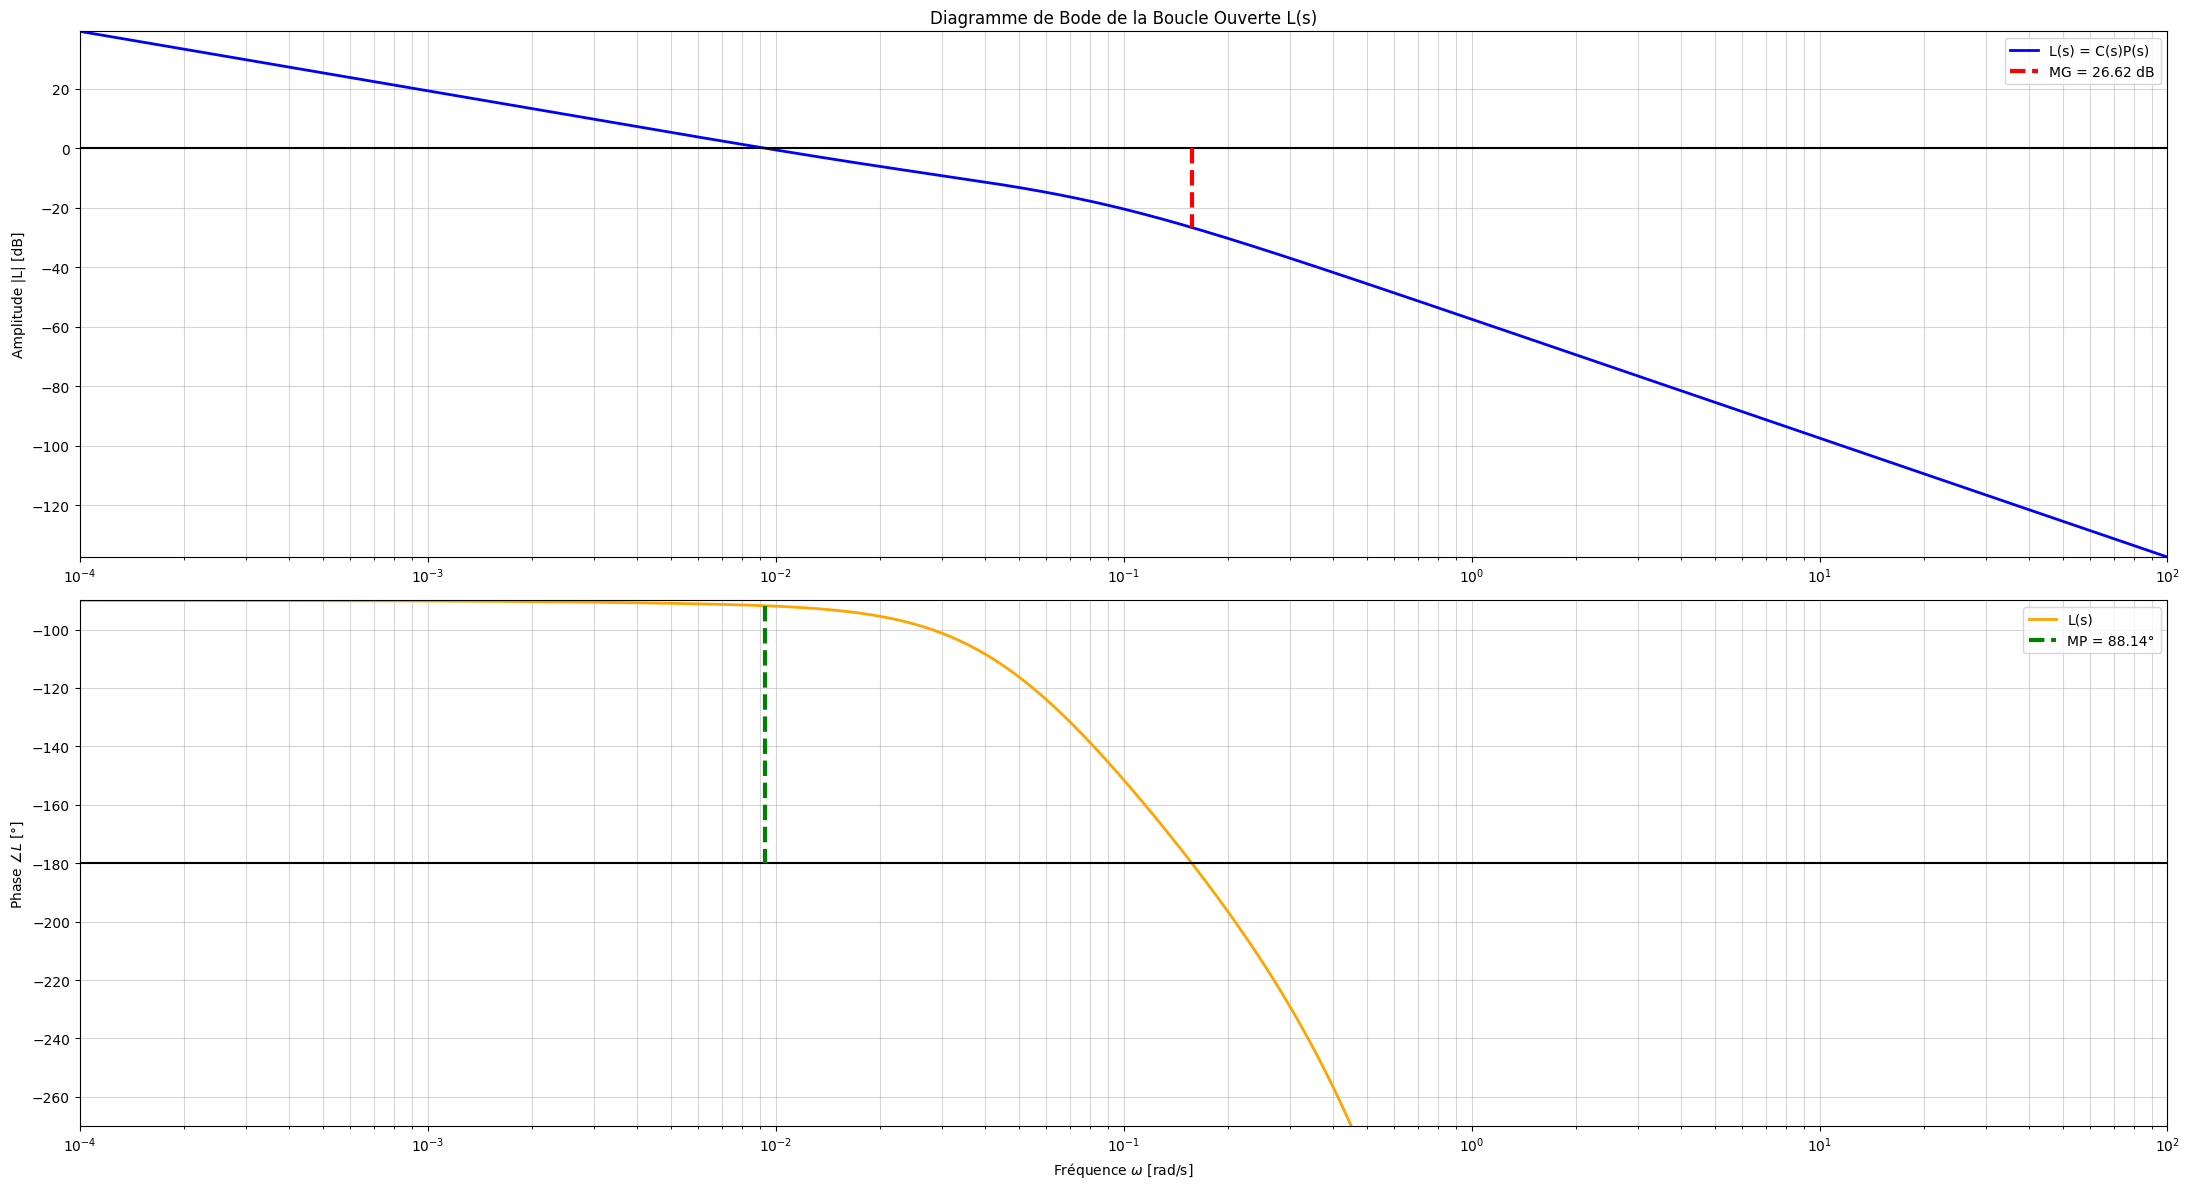

Gain margin : 26.62 dB at the ultimate frequency : 0.1567 rad/s
Phase margin : 88.14° at the crossover frequency : 0.0093 rad/s


In [14]:

#PARAMÈTRES DU SYSTÈME 
K = 0.320
T1 = 149.53
T2 = 15.07
theta = 4.00

P = Process(parameters={
    'Kp': K, 
    'Tlag1': T1, 
    'Tlag2': T2, 
    'Tlead1': 0, 
    'Tlead2': 0, 
    'theta': theta 
})


Kc_imc, Ti_imc, Td_imc = IMC_tuning(K, T1, T2, theta, gamma=0.7)


Cparams = {
    'Kc': Kc_imc,
    'Ti': Ti_imc,
    'Td': Td_imc,
    'alpha': 1
}

print(f"Paramètres calculés par IMC : Kc={Kc_imc:.3f}, Ti={Ti_imc:.2f}, Td={Td_imc:.2f}")

omega = np.logspace(-4, 2, 1000) 
MG, MP = Margin(P, Cparams, omega)